<a href="https://colab.research.google.com/github/chiquixs/jobsheet/blob/main/data-mining/jobsheet7/loan-logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving loan-train.csv to loan-train (2).csv
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0     

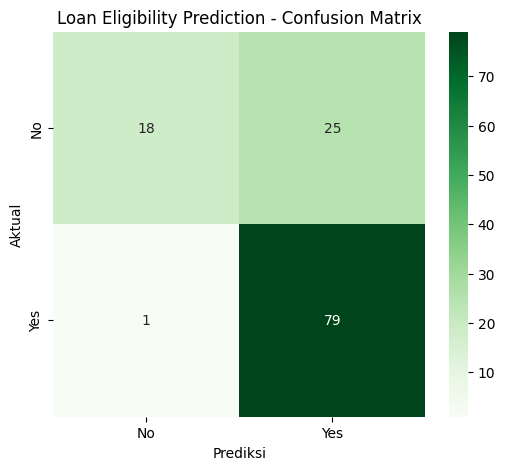

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from google.colab import files

uploaded = files.upload()

# Load Dataset
data = pd.read_csv("loan-train.csv")
print(data.head())

# handling Missing Values
# menggunakan mode untuk data kategori
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])

# menggunakan median untuk data numerik
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].median())
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].median())


# select atribut (membuat id dan gender)
x = data.drop(['Loan_ID', 'Gender', 'Loan_Status'], axis=1)
y = data['Loan_Status']

# merubah Teks menjadi Angka (Nominal to Numerical)
x = pd.get_dummies(x, drop_first=True)

# split data (80% Train, 20% Test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# train model
model = LogisticRegression(max_iter=5000)
model.fit(x_train, y_train)

# evaluasi
y_pred = model.predict(x_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# visualisasi confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Loan Eligibility Prediction - Confusion Matrix")
plt.show()
